In [1]:
# Load cleaned healthcare dataset
import pandas as pd

df = pd.read_csv("../data/processed/ckd_cleaned.csv")

In [2]:
# Dataset shape

print(df.shape)

(400, 26)


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           400 non-null    int64  
 1   age          400 non-null    float64
 2   bp           400 non-null    float64
 3   sg           400 non-null    float64
 4   al           400 non-null    float64
 5   su           400 non-null    float64
 6   pc           400 non-null    str    
 7   pcc          400 non-null    str    
 8   ba           400 non-null    str    
 9   bgr          400 non-null    float64
 10  bu           400 non-null    float64
 11  sc           400 non-null    float64
 12  sod          400 non-null    float64
 13  pot          400 non-null    float64
 14  hemo         400 non-null    float64
 15  pcv          400 non-null    float64
 16  wbcc         400 non-null    float64
 17  rbcc         400 non-null    float64
 18  htn          400 non-null    str    
 19  dm           400 no

In [4]:
# Statistical summary

df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000
mean,200.500000,51.562500,76.575000,1.017712,0.90000,0.395000,145.062500,56.693000,2.997125,137.631250,4.577250,12.54250,39.082500,8298.500000,4.737750
std,115.614301,16.982996,13.489785,0.005434,1.31313,1.040038,75.260774,49.395258,5.628886,9.206332,2.821357,2.71649,8.162245,2529.593814,0.841439
min,1.000000,2.000000,50.000000,1.005000,0.00000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.10000,9.000000,2200.000000,2.100000
25%,100.750000,42.000000,70.000000,1.015000,0.00000,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.87500,34.000000,6975.000000,4.500000
50%,200.500000,55.000000,80.000000,1.020000,0.00000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.65000,40.000000,8000.000000,4.800000
75%,300.250000,64.000000,80.000000,1.020000,2.00000,0.000000,150.000000,61.750000,2.725000,141.000000,4.800000,14.62500,44.000000,9400.000000,5.100000
max,400.000000,90.000000,180.000000,1.025000,5.00000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.80000,54.000000,26400.000000,8.000000


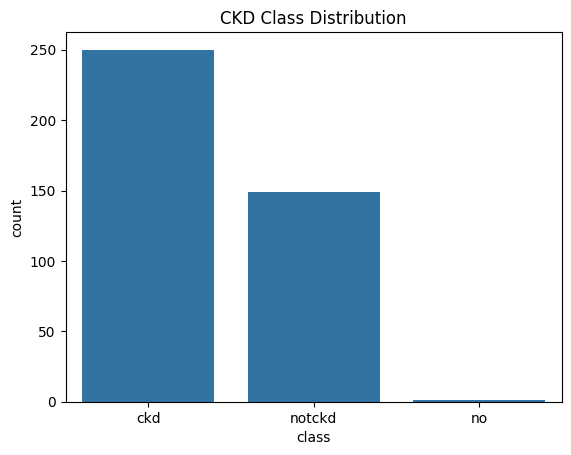

In [5]:
# CKD class distribution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='class', data=df)

plt.title("CKD Class Distribution")

plt.show()

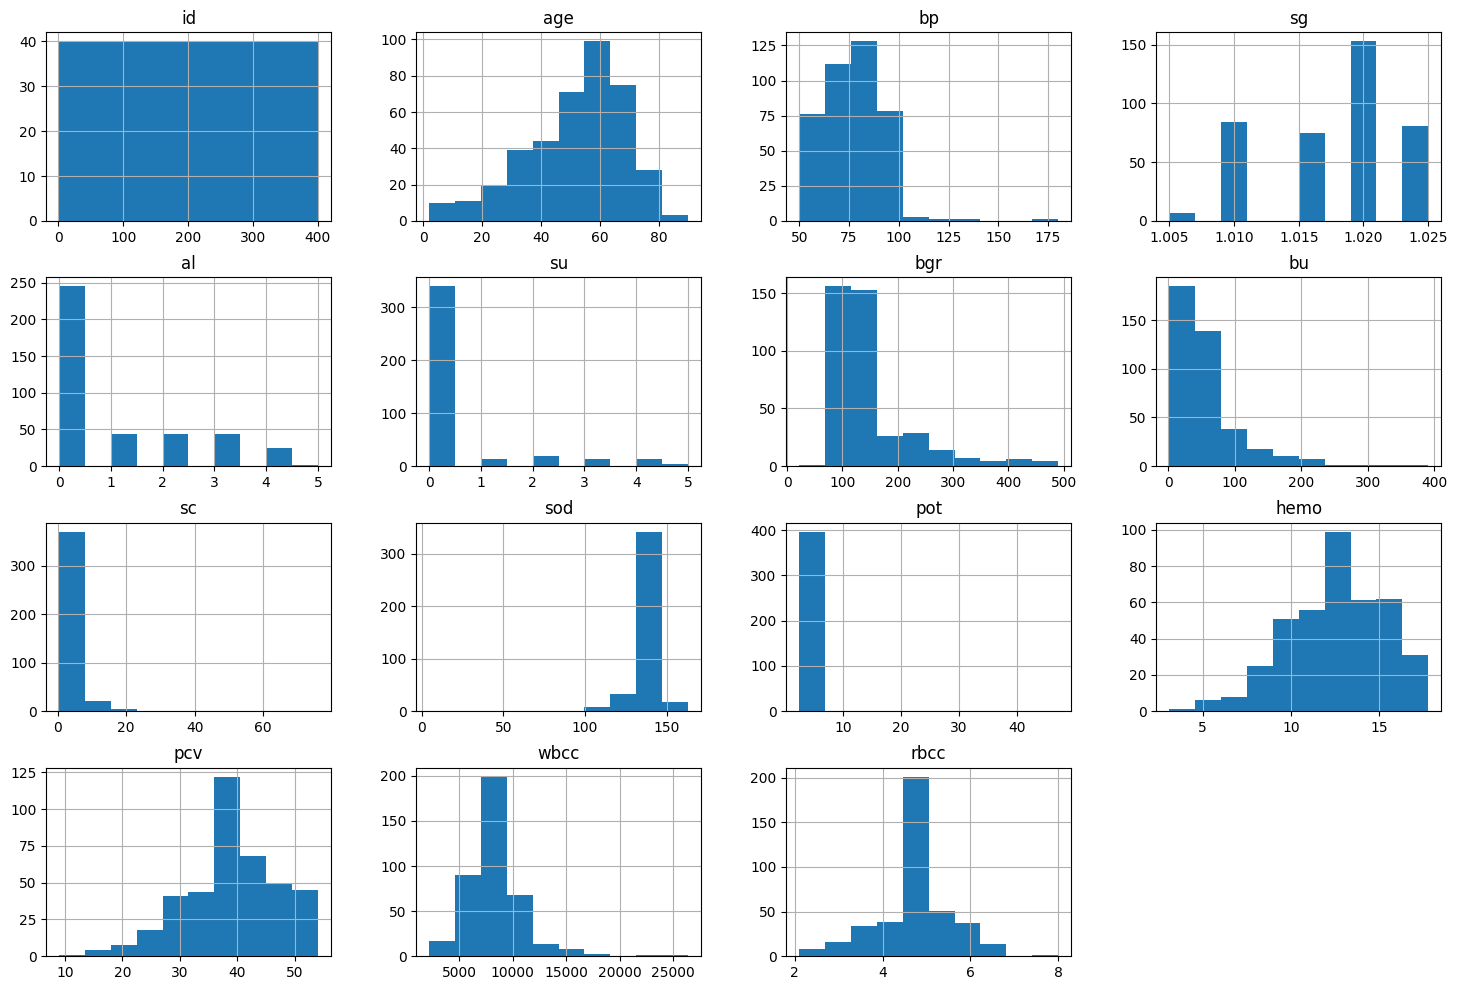

In [6]:
# Numerical feature distributions

df.hist(figsize=(18,12))

plt.show()

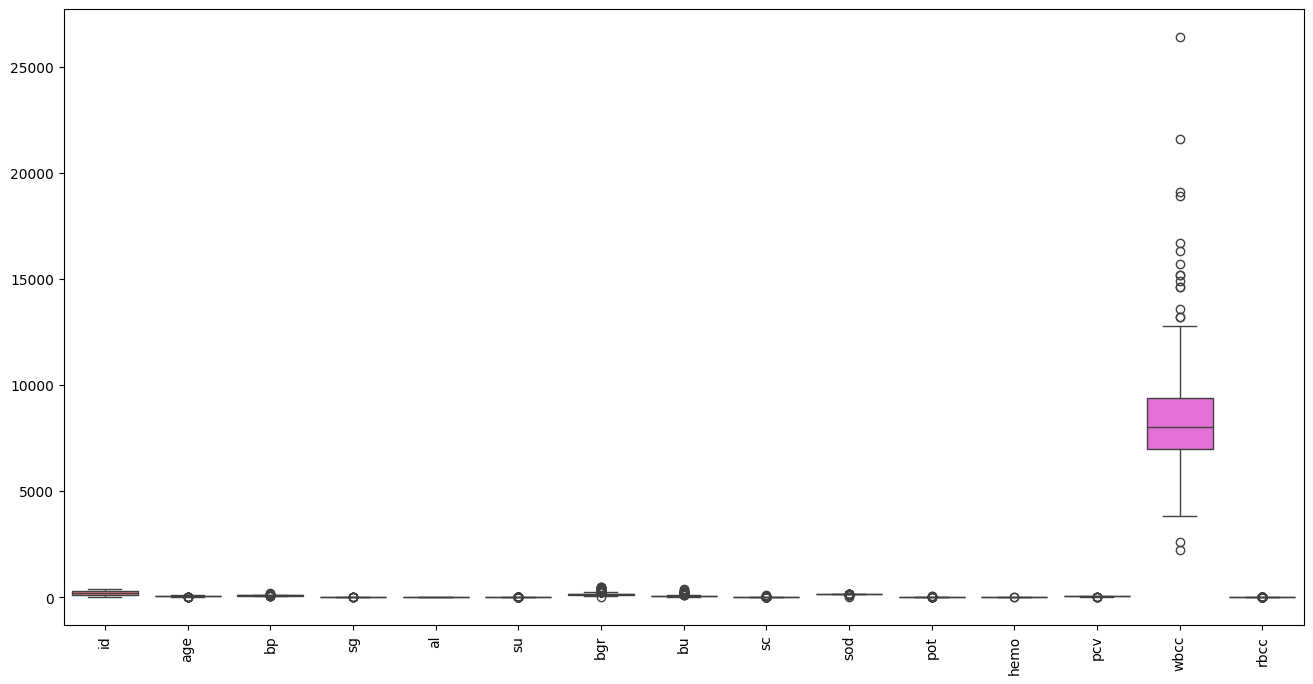

In [7]:
# Outlier visualization

plt.figure(figsize=(16,8))

sns.boxplot(data=df.select_dtypes(include='number'))

plt.xticks(rotation=90)

plt.show()

In [8]:
# Create temporary copy for correlation analysis

df_corr = df.copy()

In [9]:
# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

In [10]:
# Initialize LabelEncoder

label_encoder = LabelEncoder()

In [11]:
# Encode categorical columns for correlation analysis

for col in df_corr.select_dtypes(include='object').columns:
    
    # Convert categorical values into numerical labels
    df_corr[col] = label_encoder.fit_transform(df_corr[col])

C:\Users\user\AppData\Local\Temp\ipykernel_14464\2932698031.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include='object').columns:


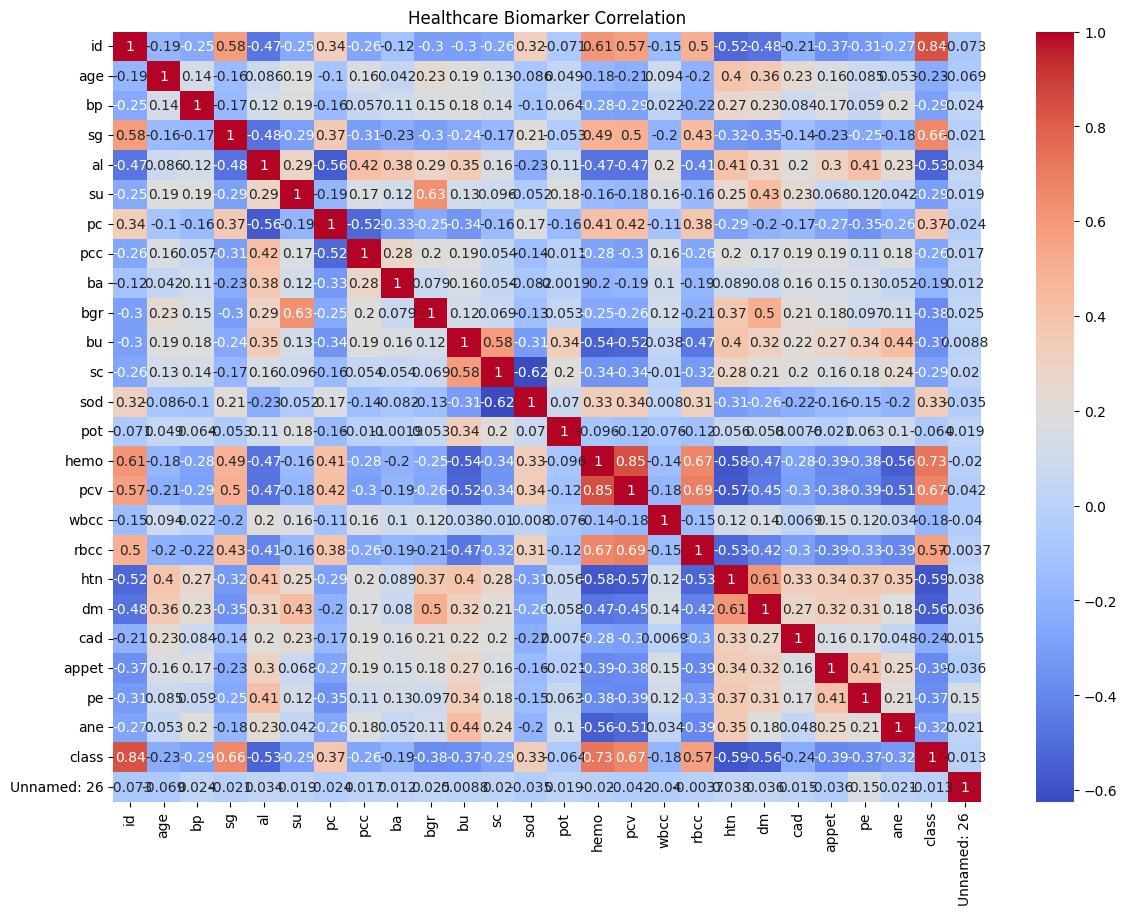

In [12]:
# Correlation analysis

plt.figure(figsize=(14,10))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Healthcare Biomarker Correlation")

plt.show()

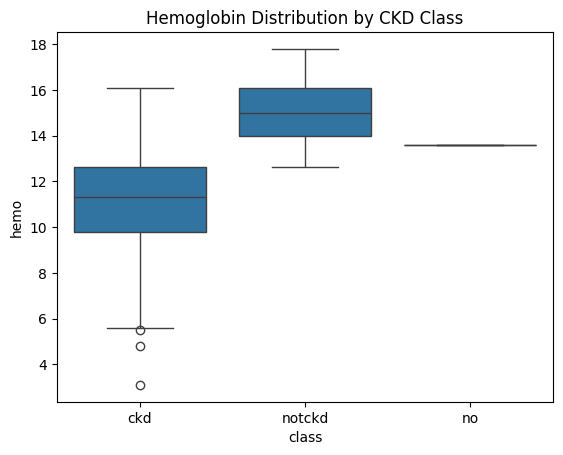

In [13]:
# Hemoglobin comparison

sns.boxplot(x='class', y='hemo', data=df)

plt.title("Hemoglobin Distribution by CKD Class")

plt.show()

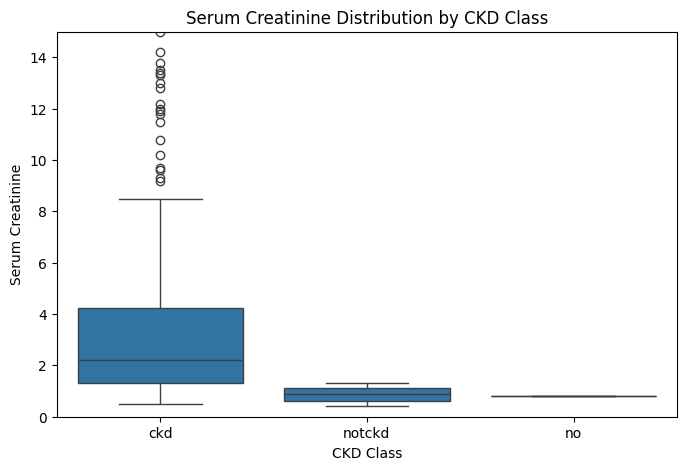

In [15]:
# ==========================================
# Serum Creatinine Distribution by CKD Class
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x='class', y='sc', data=df)

# Limit y-axis for better visualization
plt.ylim(0, 15)

plt.title("Serum Creatinine Distribution by CKD Class")

plt.xlabel("CKD Class")

plt.ylabel("Serum Creatinine")

plt.show()

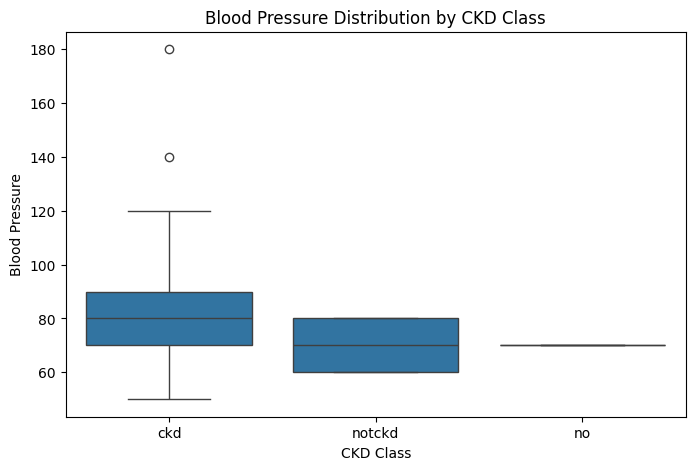

In [16]:
# ==========================================
# Blood Pressure Distribution by CKD Class
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x='class', y='bp', data=df)

plt.title("Blood Pressure Distribution by CKD Class")

plt.xlabel("CKD Class")

plt.ylabel("Blood Pressure")

plt.show()

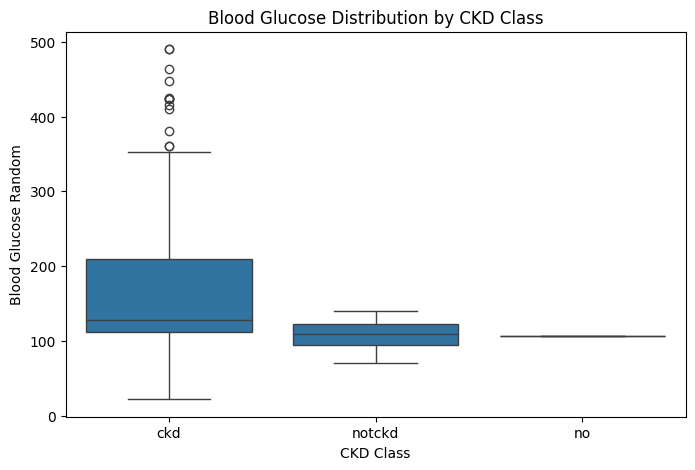

In [17]:
# ==========================================
# Blood Glucose Distribution by CKD Class
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x='class', y='bgr', data=df)

plt.title("Blood Glucose Distribution by CKD Class")

plt.xlabel("CKD Class")

plt.ylabel("Blood Glucose Random")

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14464\4256327092.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


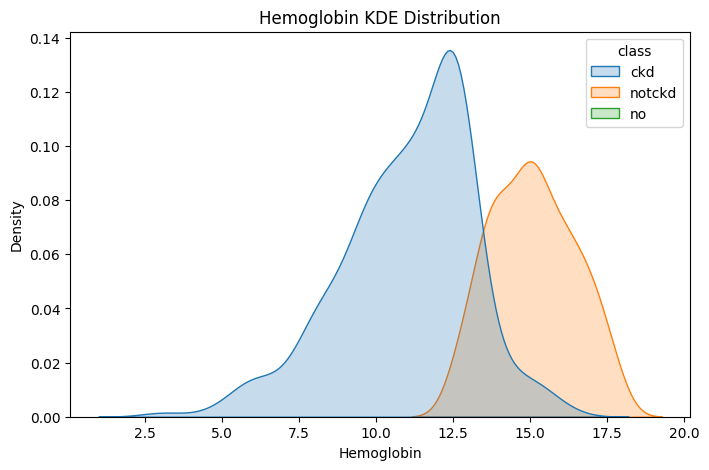

In [18]:
# ==========================================
# Hemoglobin KDE Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='hemo',
    hue='class',
    fill=True
)

plt.title("Hemoglobin KDE Distribution")

plt.xlabel("Hemoglobin")

plt.show()

In [20]:
# Check unique class values

print(df['class'].unique())

<StringArray>
['ckd', 'notckd', 'no']
Length: 3, dtype: str


In [21]:
# Check class distribution

print(df['class'].value_counts())

class
ckd       250
notckd    149
no          1
Name: count, dtype: int64


In [22]:
# Replace incorrect target label

df['class'] = df['class'].replace({
    'no': 'notckd'
})

In [23]:
# Verify cleaned class labels

print(df['class'].value_counts())

class
ckd       250
notckd    150
Name: count, dtype: int64


In [25]:
# Save corrected dataset

df.to_csv("../data/processed/ckd_cleaned.csv", index=False)

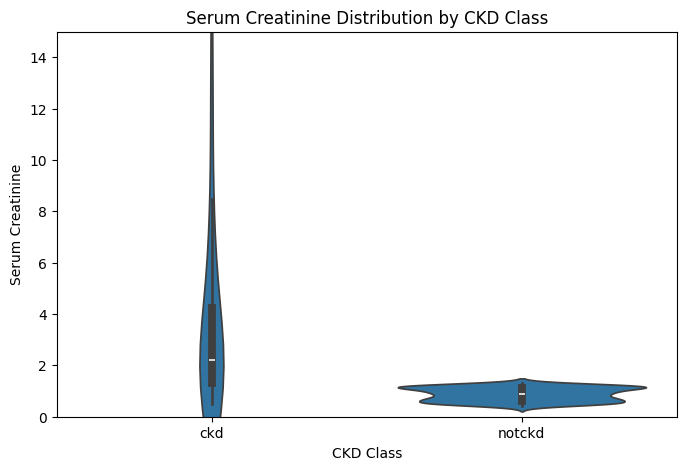

In [26]:
# ==========================================
# Serum Creatinine Violin Plot
# ==========================================

plt.figure(figsize=(8,5))

sns.violinplot(x='class', y='sc', data=df)

plt.ylim(0, 15)

plt.title("Serum Creatinine Distribution by CKD Class")

plt.xlabel("CKD Class")

plt.ylabel("Serum Creatinine")

plt.show()